# Statistical Foundations for Operations
## 💡 Concept: Distinguishing Signal from Noise

Operational data varies naturally. Is a drop in throughput due to a broken pump component or just random daily fluctuation? Statistics provides the mathematical tools to make this decision confidently.


## 🔎 Key Concepts

- Probability Distributions 📊: Models representing how data behaves over time. Examples include Normal/Gaussian (continuous variations), Poisson (discrete event counts, like accidents), and Exponential (time-to-failure lifespans).

- Hypothesis Testing ⚖️: * Null Hypothesis ($H_0$): "There is no operational difference between Group A and Group B."

- P-value: The probability of seeing our data if $H_0$ is true. If $p < 0.05$, we reject the null hypothesis and confirm that the difference is real.

- Confidence Intervals 🔒: Estimating a range where the true population parameter lies (e.g., "We are 95% confident the average repair time is between 4.2 and 5.1 hours").


## 🛠️ Applied Activity: Comparing Shift Performance

We test if the Night Shift has significantly higher operational error rates than the Day Shift, or if the variance is due to random chance.

### 💻 The Python Implementation

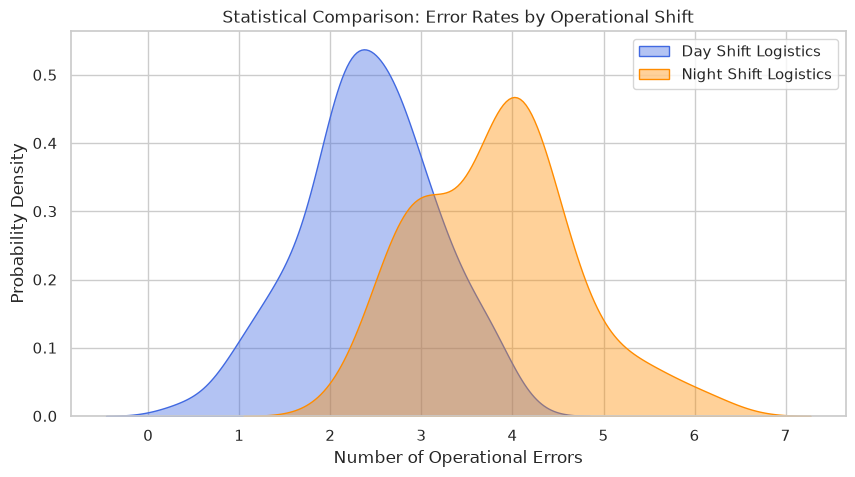

T-Statistic calculated: -12.4778
Calculated P-Value: 0.000000
Result: Statistically Significant Difference! (Reject H0)
Insight: Night shift error rates are genuinely higher, not a random fluke.

 95% Confidence Interval for Night Shift Mean: [3.65, 3.99]


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")

# --- SIMULATING OPERATIONAL SHIFT ERRORS ---
np.random.seed(42)
day_errors = np.random.normal(loc=2.5, scale=0.8, size=100)   # Mean = 2.5
night_errors = np.random.normal(loc=3.8, scale=0.9, size=100) # Mean = 3.8

# Visualize Distributions using KDE Plots
plt.figure(figsize=(10, 5))
sns.kdeplot(day_errors, label='Day Shift Logistics', fill=True, alpha=0.4, color='royalblue')
sns.kdeplot(night_errors, label='Night Shift Logistics', fill=True, alpha=0.4, color='darkorange')
plt.title('Statistical Comparison: Error Rates by Operational Shift')
plt.xlabel('Number of Operational Errors')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# Hypothesis Testing: Independent T-Test
# H0: Mean(Day) == Mean(Night)
# H1: Mean(Day) != Mean(Night)
t_stat, p_value = stats.ttest_ind(day_errors, night_errors)

print(f"T-Statistic calculated: {t_stat:.4f}")
print(f"Calculated P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically Significant Difference! (Reject H0)")
    print("Insight: Night shift error rates are genuinely higher, not a random fluke.")
else:
    print("Result: No Statistically Significant Difference. (Fail to reject H0)")
    print("Insight: The observed variation could be completely due to random chance.")

# 3. Constructing a 95% Confidence Interval for the Night Shift Mean
mean_night = np.mean(night_errors)
std_err = stats.sem(night_errors)
conf_interval = stats.t.interval(0.95, len(night_errors)-1, loc=mean_night, scale=std_err)
print(f"\n 95% Confidence Interval for Night Shift Mean: [{conf_interval[0]:.2f}, {conf_interval[1]:.2f}]")

# Regression & Forecasting Basics
## 💡 Concept: Predicting Continuous Values

Operational managers want to know what lies ahead: How much fuel will our fleet need next month? At what exact hour will this storage tank empty? Regression analysis maps out relationships to forecast these values.

## 📈 Evaluation Metrics

- MAE (Mean Absolute Error) 🎯: The average absolute distance between predictions and actual values. Easy to explain to business stakeholders (e.g., "Our model is off by an average of 15 barrels").

- RMSE (Root Mean Squared Error) 📐: Penalizes larger errors more heavily, making it useful for catching significant planning misses.

- R-Squared ($R^2$) ⚖️: The proportion of variance explained by the model, ranging from $0$ to $1$. An $R^2$ of $0.85$ means your features capture 85% of the underlying patterns.


## 🛠️ Applied Activity: Predicting Pipeline Throughput

We will build a multiple linear regression model to forecast asset throughput based on telemetry inputs: system pressure and ambient operating temperatures.

### 💻 The Python Implementation

In [2]:
# --- MODULE 2: REGRESSION & FORECASTING ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Generate synthetic industrial parameters
np.random.seed(42)
data = {
    'pressure_psi': np.random.uniform(100, 150, 500),
    'temp_c': np.random.uniform(20, 40, 500),
    'throughput_bbl': []
}

# Underlying physical law: Throughput = 10*Pressure - 5*Temp + Noise
for p, t in zip(data['pressure_psi'], data['temp_c']):
    val = (10 * p) - (5 * t) + np.random.normal(0, 50)
    data['throughput_bbl'].append(max(0, val))

df_reg = pd.DataFrame(data)

# Isolate Features (X) and Target Variable (y)
X = df_reg[['pressure_psi', 'temp_c']]
y = df_reg['throughput_bbl']

# Segment into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression Engine
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Regression Pipeline Results ===")
print(f"Engine Coefficients: Pressure Weight = {model.coef_[0]:.2f}, Temp Weight = {model.coef_[1]:.2f}")
print(f"Model Intercept Constant: {model.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} barrels")
print(f"R-Squared Score (R²): {r2:.2f} ({r2*100:.1f}% of variance explained)")

# Executive Translation:
# "For every 1 psi increase in system pressure, throughput increases by ~10 barrels, 
# while a 1°C increase in temperature introduces a loss of ~5 barrels."

=== Regression Pipeline Results ===
Engine Coefficients: Pressure Weight = 9.63, Temp Weight = -4.97
Model Intercept Constant: 51.52
Mean Absolute Error (MAE): 42.00 barrels
R-Squared Score (R²): 0.89 (88.7% of variance explained)


# Sensor Data & Predictive Maintenance (PdM)
## 💡 Concept: Feature Engineering for Hardware Health

Raw high-frequency IoT streaming data is noisy. To train predictive models effectively, you must extract meaningful Features that accurately reflect the internal health of the machinery.
```
 ┌──────────────────────┐      ┌─────────────────────────┐      ┌──────────────────────┐
 │ Raw Sensor Stream    │ ───> │ Feature Engineering     │ ───> │ Machine Learning     │
 │ High-frequency noise │      │ Extract RMS & Roll Mean │      │ Predict Failure / RUL│
 └──────────────────────┘      └─────────────────────────┘      └──────────────────────┘
```

## ⚙️ Time-Domain Feature Extractions

- Rolling Mean 🌊: Smooths out transient high-frequency spikes to reveal the underlying degradation trend.

- Root Mean Square (RMS) ⚡: Measures the total kinetic energy within the vibration signal. Increasing RMS values typically point to bearing wear, unbalance, or structural degradation.

- Failure Modes & Effects Analysis (FMEA) 📋: A structured approach to identifying all potential failure modes within a system, determining their operational impacts, and prioritizing maintenance tasks.


## 🛠️ Applied Activity: Extracting Health Features from Vibration Data

We simulate a industrial pump asset degrading over 100 days. We will extract rolling time-domain indicators to build a machine health status classifier.

### 💻 The Python Implementation

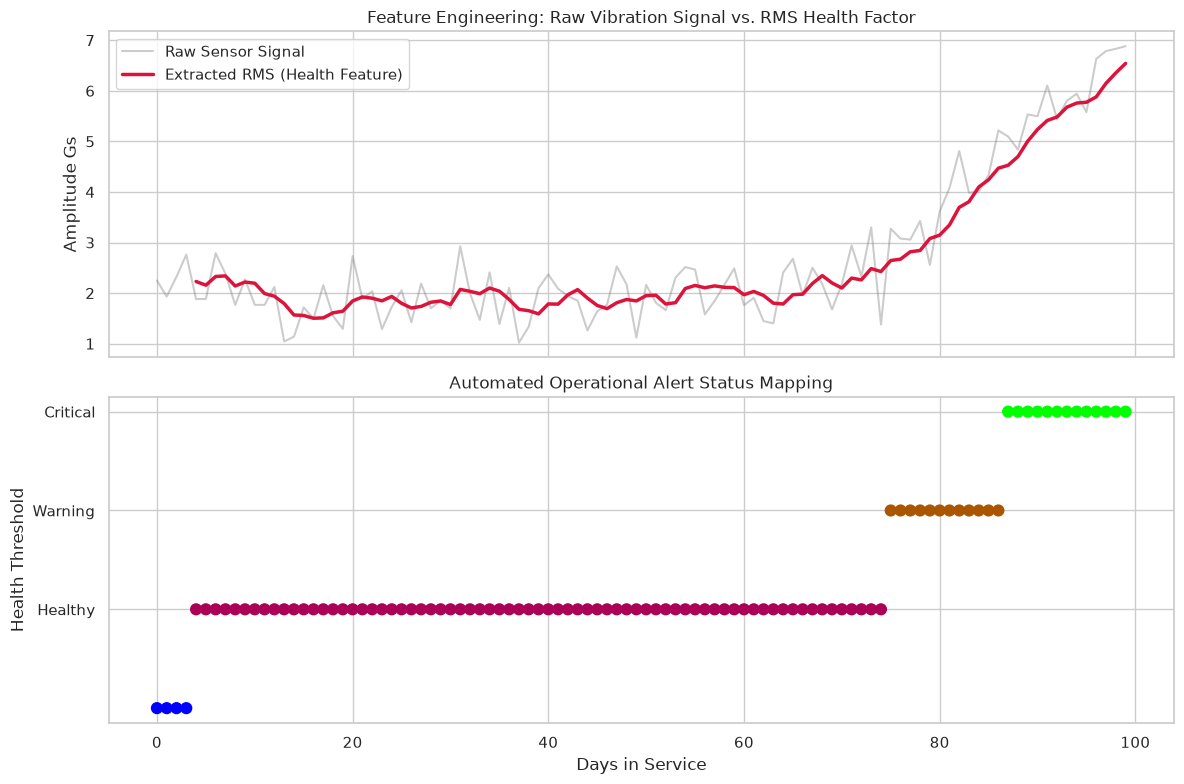

Operational health features extracted successfully. The engineered RMS factor effectively flags the degradation curve.


In [3]:
# --- MODULE 3: SENSOR DATA & FEATURE ENGINEERING ---
np.random.seed(42)
days = np.arange(100)

# Simulate baseline vibration signature + a sharp wear trend after Day 70
vibration_raw = 2.0 + (np.random.normal(0, 0.5, 100))
vibration_raw[70:] += np.linspace(0, 5, 30)  # Micro-degradation phase

df_sensor = pd.DataFrame({'day': days, 'vibration_raw': vibration_raw})

# Feature Engineering: 5-Day Rolling Statistical Window
window_size = 5
df_sensor['vib_rms'] = np.sqrt(df_sensor['vibration_raw']**2).rolling(window=window_size).mean()
df_sensor['vib_mean'] = df_sensor['vibration_raw'].rolling(window=window_size).mean()
df_sensor['vib_max'] = df_sensor['vibration_raw'].rolling(window=window_size).max()

# Establish categorical machine health zones based on RMS values
df_sensor['health_status'] = pd.cut(
    df_sensor['vib_rms'], 
    bins=[-np.inf, 2.5, 4.5, np.inf], 
    labels=['Healthy', 'Warning', 'Critical']
)

# Visualizing the Degradation Pipeline
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Signal vs. Extracted Health Feature
ax[0].plot(df_sensor['day'], df_sensor['vibration_raw'], label='Raw Sensor Signal', alpha=0.4, color='gray')
ax[0].plot(df_sensor['day'], df_sensor['vib_rms'], label='Extracted RMS (Health Feature)', color='crimson', linewidth=2.5)
ax[0].set_title('Feature Engineering: Raw Vibration Signal vs. RMS Health Factor')
ax[0].set_ylabel('Amplitude Gs')
ax[0].legend(loc='upper left')
ax[0].grid(True)

# Bottom Plot: Classification of Derived Health Status
ax[1].scatter(df_sensor['day'], df_sensor['health_status'].cat.codes, c=df_sensor['health_status'].cat.codes, cmap='brg', s=60, zorder=3)
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(['Healthy', 'Warning', 'Critical'])
ax[1].set_title('Automated Operational Alert Status Mapping')
ax[1].set_xlabel('Days in Service')
ax[1].set_ylabel('Health Threshold')
ax[1].grid(True)

plt.tight_layout()
plt.show()

print("Operational health features extracted successfully. The engineered RMS factor effectively flags the degradation curve.")

# Soft Skills Thread - Cross-Industry Translation
## ⚡ Activity: The "Two Audiences" Brief

As an analyst, your value depends heavily on your communication skills. You need to be able to explain the exact same predictive model to different types of stakeholders by adjusting your vocabulary and focus.


## 👥 The Assignment

Using the predictive maintenance model built in Module 3, draft two distinct summary briefs tailored for different internal stakeholders:


### 🔀 Audience Profile Breakdown
#### 🛠️ Profile 1: The Engineering Team

- Primary Focus: Sensor sensitivity, false positive vs. false negative trade-offs, instrument placement, and specific maintenance windows.

- Permitted Jargon: `RMS Thresholds`, `Nyquist Frequency`, `FMEA`, `MTBF`, `Sensor Calibration`.

- Core Goal: Build technical alignment so engineers trust the model's flags and can plan maintenance windows effectively.

### 💼 Profile 2: The Chief Financial Officer (CFO)

- Primary Focus: Risk mitigation, return on investment (ROI), asset lifespan extension, and cost reductions.

- Permitted Jargon: Strictly business terms— `Capital Allocation Efficiency`, `Net Margin Savings`, `Unplanned Liability Reduction`. No technical jargon allowed!

- Core Goal: Provide a clear economic case for the model by showing how preventing a single asset failure protects the company's bottom line